In [1]:
# Cell 0: PNG Export Fix (run once)
import sys
!{sys.executable} -m pip install kaleido --force-reinstall
print("🔄 Restart kernel after this!")


zsh:1: no such file or directory: /Users/tinashe/Climate
🔄 Restart kernel after this!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

plt.style.use("seaborn-v0_8") 

print("Libraries imported OK")


Libraries imported OK


In [3]:
import pandas as pd

df = pd.read_csv(
	"/Users/tinashe/Climate Analysis Project/climate-trends/data:/gistemp_global_annual.txt",
	sep=r"\s+",
	skiprows=7,
	usecols=[0, 13],
	names=["year", "ann_mean"],
)

df['year']= pd.to_numeric(df['year'], errors="coerce")
df['ann_mean']= pd.to_numeric(df['ann_mean'], errors='coerce')

df["anomaly_degC"] = df["ann_mean"] / 100.0

df = df.dropna(subset=["anomaly_degC"]).sort_values("year").reset_index(drop=True)

print("Data loaded!")
print(f"Years: {df['year'].min()} to {df['year'].max()}")
print(f" {len(df)} complete years")
print("\nFirst 5 rows:")
print(df.head())
print("\nLast 5 rows:")
print(df.tail())

Data loaded!
Years: 1880.0 to 2025.0
 146 complete years

First 5 rows:
     year  ann_mean  anomaly_degC
0  1880.0     -18.0         -0.18
1  1881.0     -10.0         -0.10
2  1882.0     -12.0         -0.12
3  1883.0     -18.0         -0.18
4  1884.0     -29.0         -0.29

Last 5 rows:
       year  ann_mean  anomaly_degC
141  2021.0      85.0          0.85
142  2022.0      90.0          0.90
143  2023.0     117.0          1.17
144  2024.0     128.0          1.28
145  2025.0     119.0          1.19


Plot saved


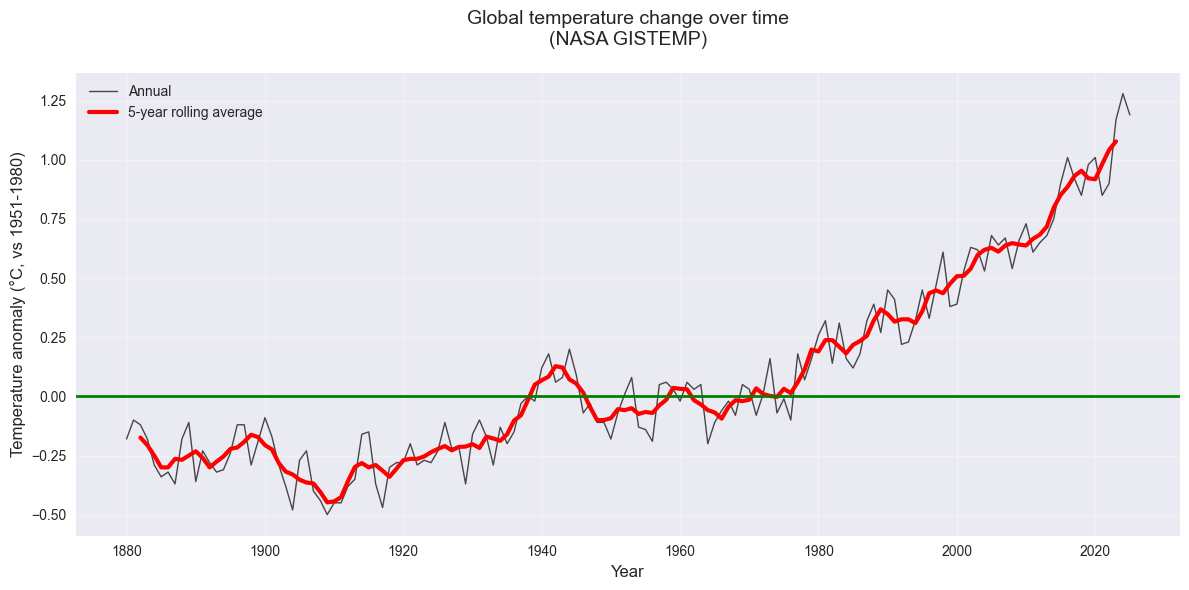

In [4]:
import matplotlib.pyplot as plt

# Plot 1: Global temperature anomaly over time
plt.figure(figsize=(12,6))


# Annual data plot (Black)
plt.plot(df['year'], df['anomaly_degC'],color="black", alpha=0.7, linewidth=1, label='Annual')

# 5 year rolling average (Red)
df['rolling_5yr'] = df['anomaly_degC'].rolling(window=5, center=True).mean()
plt.plot(df['year'], df['rolling_5yr'], color="red", linewidth=3, label='5-year rolling average' )

# baseline 0°C
plt.axhline(y=0, color="green", linewidth=2)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Temperature anomaly (°C, vs 1951-1980)", fontsize=12 )
plt.title("Global temperature change over time\n(NASA GISTEMP)", fontsize=14, pad=20)
plt.legend()
plt.grid(True, alpha=0.3)

# saving plot to figures/ folder
plt.savefig("/Users/tinashe/Climate Analysis Project/climate-trends/figures/global_temp_timeseries.png", dpi=300, bbox_inches='tight')

print("Plot saved")

plt.tight_layout()
plt.show()




Stripes saved!


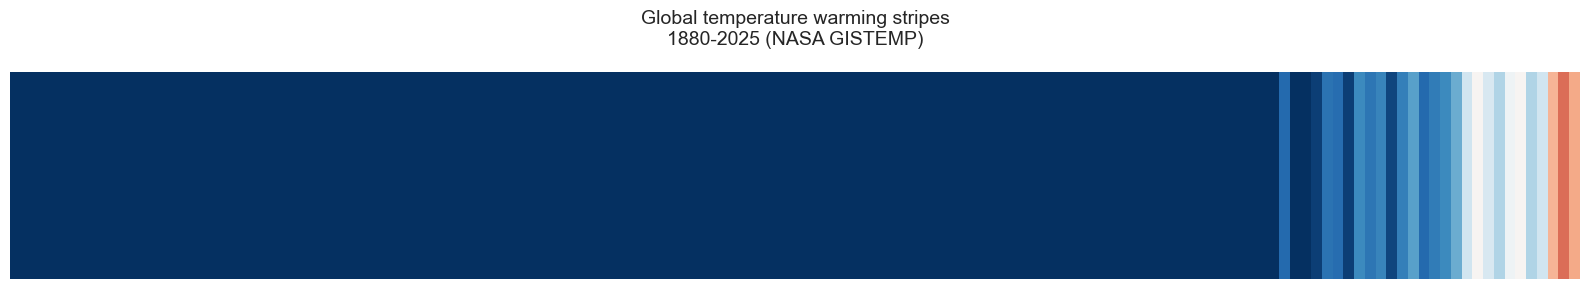

In [5]:
# Plot 2 Warming Stripes (each year = one colored stripe)
plt.figure(figsize=(16, 3))

stripe_data = df['anomaly_degC'].values.reshape(1, -1)

plt.imshow(stripe_data, cmap="RdBu_r", aspect='auto', vmin=0.5, vmax=1.5)

plt.axis('off')
plt.title("Global temperature warming stripes\n1880-2025 (NASA GISTEMP)", pad=20, fontsize=14)

plt.savefig("../figures/warming_stripes.png", dpi=300, bbox_inches="tight", facecolor="white", pad_inches=0.1)
print("Stripes saved!")

plt.tight_layout()
plt.show()



In [6]:
# Key findings
print("KEY FINDINGS")
print(f"Warmest year: {df.loc[df['anomaly_degC'].idxmax(), 'year']:.0f} " f"({df['anomaly_degC'].max():.2f}°C")

print(f"Coolest year: {df.loc[df['anomaly_degC'].idxmin(), 'year']:.0f} " f"({df['anomaly_degC'].min():.2f}°C")

early = df[df['year'] <=1900]['anomaly_degC'].mean()
recent = df[df['year'] >= 2015]['anomaly_degC'].mean()

print(f"1880 -1900 avg: {early:.2f}°C")
print(f"2015 -2025 avg: {recent:.2f}°C")
print(f"Change: +{recent - early:.2f}°C")


KEY FINDINGS
Warmest year: 2024 (1.28°C
Coolest year: 1909 (-0.50°C
1880 -1900 avg: -0.23°C
2015 -2025 avg: 1.01°C
Change: +1.23°C
